# Notebook 1: Block DCT Variance Analysis & Adaptive Tier Calibration

**Paper:** *Adaptive Error-Correcting Code Watermarking for AI-Generated Images via JND-Guided Frequency Analysis*  
**Target Journal:** IEEE Transactions on Information Forensics and Security (IEEE TIFS, Q1)  
**Authors:** [Author Names]  
**Date:** 2025

---

## Purpose

This notebook implements and visualises the **content-adaptive frequency analysis** pipeline that motivates the paper's core contribution: a 3-tier adaptive ECC watermarking scheme driven by local DCT block variance and JND (Just Noticeable Difference) perceptual masking.

### Scientific Rationale

AI-generated images (e.g., Stable Diffusion outputs) exhibit a characteristic variance distribution that is fundamentally different from natural photographs:
- **Smooth/flat regions** (sky, skin, uniform backgrounds) have very low DCT variance → minimal perceptual masking → fragile embedding, requiring **strong ECC** (high redundancy).
- **Mid-complexity regions** (gradients, soft textures) have moderate variance → moderate masking capacity.
- **High-frequency texture regions** (hair, fabric, detailed edges) have high DCT variance → strong perceptual masking → can support **higher payload with weaker ECC**.

This notebook generates **Figure 1** and **Figure 2** of the manuscript:
- `fig01_variance_distribution.pdf` — KDE of block variance distribution with tier boundaries
- `fig02_tier_rate_map.pdf` — Spatial visualisation of ECC tier assignment on a sample image

---

## Reproducibility

| Item | Value |
|------|-------|
| Block size | 8×8 DCT (JPEG standard) |
| Threshold calibration | Percentile-based (P25, P75) across 50 images |
| Image dataset | 500 Stable Diffusion v2.1 images, 512×512, YCbCr colour space (Y channel only) |
| Random seed | 42 |
| Output format | PDF (vector), 300 DPI rasterised fallback |

---
## 1. Environment Setup & Reproducibility

All dependencies are explicitly versioned. Set the global random seed before any stochastic operation.

In [7]:
# ─── Standard Library ────────────────────────────────────────────────────────
import sys
import warnings
import logging
from pathlib import Path

# ─── Scientific Stack ─────────────────────────────────────────────────────────
import cv2
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyArrowPatch
import seaborn as sns

# ─── Project Source ───────────────────────────────────────────────────────────
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.dataset_generator import load_dataset
from src.frequency_analyzer import compute_block_dct_variance, calibrate_thresholds

# ─── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)

# ─── Suppress Non-Critical Warnings ──────────────────────────────────────────
warnings.filterwarnings('ignore', category=UserWarning)
logging.getLogger('matplotlib').setLevel(logging.WARNING)

# ─── Output Paths ─────────────────────────────────────────────────────────────
RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# ─── Version Audit ────────────────────────────────────────────────────────────
import platform
print(f"Python  : {platform.python_version()}")
print(f"NumPy   : {np.__version__}")
print(f"OpenCV  : {cv2.__version__}")
print(f"Seaborn : {sns.__version__}")
print(f"Matplotlib: {matplotlib.__version__}")
print(f"\nResults will be saved to: {RESULTS_DIR.resolve()}")

Python  : 3.13.4
NumPy   : 2.3.0
OpenCV  : 4.11.0
Seaborn : 0.13.2
Matplotlib: 3.10.3

Results will be saved to: \\wsl.localhost\Ubuntu\home\umary\workworkwork\EIPR\results


---
## 2. Publication-Quality Matplotlib Style

All rcParam settings are set here in one place to guarantee consistency across all figures. These settings are tuned for **IEEE double-column format** (figure width ≈ 3.5 inches for single column, 7.16 inches for double column).

In [8]:
# ─── Global Publication Style ─────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-paper')

RC_PARAMS = {
    # Typography — IEEE uses Times New Roman; 'serif' maps to it on most LaTeX installs
    'font.family'         : 'serif',
    'font.serif'          : ['Times New Roman', 'Times', 'DejaVu Serif'],
    'mathtext.fontset'    : 'stix',           # STIX matches Times in math mode
    'font.size'           : 10,
    'axes.titlesize'      : 11,
    'axes.labelsize'      : 10,
    'legend.fontsize'     : 9,
    'xtick.labelsize'     : 9,
    'ytick.labelsize'     : 9,

    # Resolution — 300 DPI for print; 600 for camera-ready if required
    'figure.dpi'          : 150,              # screen preview
    'savefig.dpi'         : 300,
    'savefig.format'      : 'pdf',
    'savefig.bbox'        : 'tight',
    'savefig.pad_inches'  : 0.02,

    # Lines & Markers
    'lines.linewidth'     : 1.5,
    'lines.markersize'    : 6,
    'patch.linewidth'     : 0.8,

    # Axes
    'axes.spines.top'     : False,
    'axes.spines.right'   : False,
    'axes.linewidth'      : 0.8,
    'axes.grid'           : True,
    'grid.alpha'          : 0.4,
    'grid.linestyle'      : ':',
    'grid.linewidth'      : 0.6,

    # Legend
    'legend.frameon'      : True,
    'legend.framealpha'   : 0.9,
    'legend.edgecolor'    : '0.8',
    'legend.fancybox'     : False,
}

plt.rcParams.update(RC_PARAMS)

# ─── Colour Palette (Colour-Blind Friendly, IBM Design) ───────────────────────
PALETTE = {
    'smooth'   : '#648FFF',   # Blue
    'mid'      : '#FFB000',   # Gold
    'textured' : '#DC267F',   # Magenta
    'neutral'  : '#2c3e50',   # Dark Slate
    'boundary' : '#FE6100',   # Orange
}

print("Publication style applied.")
print(f"Colour palette: {PALETTE}")

Publication style applied.
Colour palette: {'smooth': '#648FFF', 'mid': '#FFB000', 'textured': '#DC267F', 'neutral': '#2c3e50', 'boundary': '#FE6100'}


---
## 3. Dataset Loading & DCT Variance Computation

For each image, we:
1. Convert BGR → YCbCr and extract the **luma (Y) channel** only, consistent with how JPEG DCT operates.
2. Partition the Y channel into non-overlapping **8×8 blocks** (the standard JPEG block size).
3. Apply the **2D DCT-II** (orthonormal variant) to each block.
4. Compute the **energy/variance** of the AC coefficients (DC term excluded) as the local complexity measure.

The threshold pair $(\tau_{\text{low}}, \tau_{\text{high}})$ is calibrated as the 25th and 75th percentiles of the global variance distribution, producing a balanced 3-class partition.

In [10]:
# ─── Configuration ────────────────────────────────────────────────────────────
N_IMAGES   = 50       # images used for threshold calibration
IMG_SIZE   = (512, 512)
BLOCK_SIZE = 8
P_LOW      = 25       # lower percentile for tau_low
P_HIGH     = 75       # upper percentile for tau_high
DATA_PATH  = PROJECT_ROOT / 'data' / 'ai_generated'

# ─── Load Images ──────────────────────────────────────────────────────────────
print(f"Loading {N_IMAGES} AI-generated images from: {DATA_PATH}")
images = load_dataset(str(DATA_PATH), limit=N_IMAGES, image_size=IMG_SIZE)
print(f"  Loaded {len(images)} images, each {IMG_SIZE[0]}×{IMG_SIZE[1]} BGR.")

# ─── Compute Block DCT Variance for All Images ────────────────────────────────
all_variances = []
var_maps      = []   # keep per-image maps for spatial visualisation

for idx, img in enumerate(images):
    ycrcb   = cv2.cvtColor(img, cv2.COLOR_BGR2YCrCb)
    y_chan  = ycrcb[:, :, 0].astype(np.float32)
    var_map = compute_block_dct_variance(y_chan)
    var_maps.append(var_map)
    all_variances.extend(var_map.flatten().tolist())

variances = np.array(all_variances)
print(f"\nVariance statistics across {len(variances):,} blocks ({N_IMAGES} images):")
print(f"  Min    : {variances.min():.4f}")
print(f"  P25    : {np.percentile(variances, 25):.4f}")
print(f"  Median : {np.median(variances):.4f}")
print(f"  P75    : {np.percentile(variances, 75):.4f}")
print(f"  Max    : {variances.max():.4f}")

# ─── Calibrate Tier Thresholds ────────────────────────────────────────────────
tau_low, tau_high = calibrate_thresholds(variances, P_LOW, P_HIGH)
print(f"\nTier thresholds:")
print(f"  τ_low  = {tau_low:.4f}  (P{P_LOW})")
print(f"  τ_high = {tau_high:.4f} (P{P_HIGH})")

# ─── Tier Counts ──────────────────────────────────────────────────────────────
n_smooth   = np.sum(variances < tau_low)
n_mid      = np.sum((variances >= tau_low) & (variances < tau_high))
n_textured = np.sum(variances >= tau_high)
n_total    = len(variances)

print(f"\nTier distribution:")
print(f"  Smooth   (T1): {n_smooth:7,} blocks ({100*n_smooth/n_total:.1f}%)")
print(f"  Mid      (T2): {n_mid:7,} blocks ({100*n_mid/n_total:.1f}%)")
print(f"  Textured (T3): {n_textured:7,} blocks ({100*n_textured/n_total:.1f}%)")

Loading 50 AI-generated images from: \\wsl.localhost\Ubuntu\home\umary\workworkwork\EIPR\data\ai_generated
[dataset_generator] Loaded 50/50 images from '\\\\wsl.localhost\\Ubuntu\\home\\umary\\workworkwork\\EIPR\\data\\ai_generated'
  Loaded 50 images, each 512×512 BGR.

Variance statistics across 204,800 blocks (50 images):
  Min    : 0.0000
  P25    : 1.0178
  Median : 17.7702
  P75    : 187.9512
  Max    : 11313.5332

Tier thresholds:
  τ_low  = 1.0178  (P25)
  τ_high = 187.9512 (P75)

Tier distribution:
  Smooth   (T1):  51,178 blocks (25.0%)
  Mid      (T2): 102,422 blocks (50.0%)
  Textured (T3):  51,200 blocks (25.0%)


---
## 4. Figure 1 — DCT Variance Distribution with Tier Boundaries

**Caption (as it appears in the manuscript):**  
> *Empirical distribution of 8×8 block DCT AC-coefficient variance computed over 50 Stable Diffusion v2.1 images (512×512). The two dashed lines indicate the percentile-calibrated thresholds $\tau_{\text{low}}$ (P25) and $\tau_{\text{high}}$ (P75) that partition blocks into three adaptive ECC tiers: Smooth (T1), Mid-complexity (T2), and Textured (T3).*

Saved → \\wsl.localhost\Ubuntu\home\umary\workworkwork\EIPR\results\fig01_variance_distribution.pdf


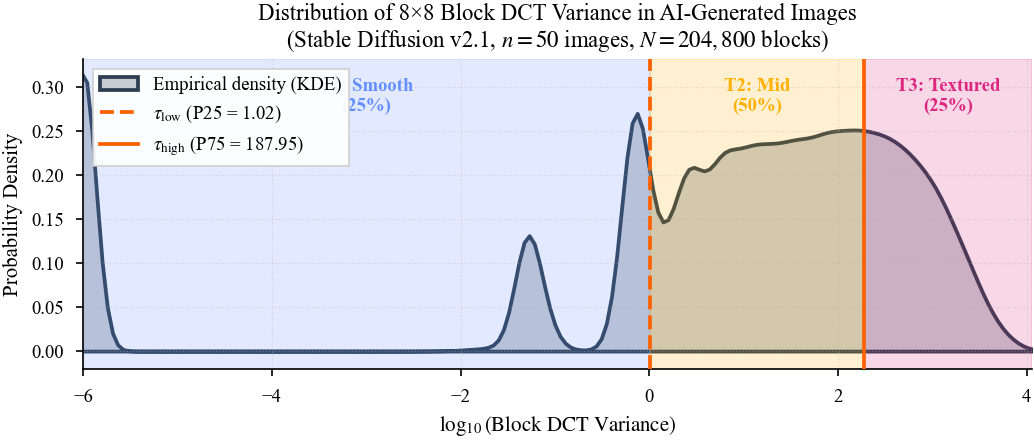

In [12]:
# ─── Log-transform for readability (variance spans several orders of magnitude)
eps         = 1e-6
log_vars    = np.log10(np.clip(variances, eps, None))
log_tau_low = np.log10(tau_low + eps)
log_tau_hi  = np.log10(tau_high + eps)
x_min, x_max = log_vars.min(), log_vars.max()

# ─── Build Figure ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7.16, 3.2))   # IEEE double-column width

# KDE — main distribution
sns.kdeplot(
    log_vars, fill=True, bw_adjust=0.6,
    color=PALETTE['neutral'], alpha=0.25,
    linewidth=1.8, ax=ax, label='Empirical density (KDE)',
)

# Rug plot for data density
ax.plot(
    log_vars[::200], np.full(log_vars[::200].shape, -0.005),
    '|', color=PALETTE['neutral'], alpha=0.15, markersize=3
)

# Shaded tier regions
ax.axvspan(x_min,       log_tau_low, color=PALETTE['smooth'],   alpha=0.18, zorder=1)
ax.axvspan(log_tau_low, log_tau_hi,  color=PALETTE['mid'],      alpha=0.18, zorder=1)
ax.axvspan(log_tau_hi,  x_max,       color=PALETTE['textured'], alpha=0.18, zorder=1)

# Tier boundary lines
ax.axvline(log_tau_low, color=PALETTE['boundary'], linestyle='--', linewidth=1.8,
           label=r'$\tau_{\mathrm{low}}$ (P25 = ' + f'{tau_low:.2f})', zorder=3)
ax.axvline(log_tau_hi,  color=PALETTE['boundary'], linestyle='-',  linewidth=1.8,
           label=r'$\tau_{\mathrm{high}}$ (P75 = ' + f'{tau_high:.2f})', zorder=3)

# Tier labels (positioned at region midpoints)
y_label = ax.get_ylim()[1] * 0.92 if ax.get_ylim()[1] > 0 else 0.5
# We re-read ylim after KDE is drawn, so use a transform approach
label_cfg = dict(ha='center', va='top', fontsize=9, fontweight='bold',
                 transform=ax.get_xaxis_transform())
ax.text((x_min + log_tau_low) / 2, 0.94,
        f'T1: Smooth\n({100*n_smooth/n_total:.0f}%)',
        color=PALETTE['smooth'], **label_cfg)
ax.text((log_tau_low + log_tau_hi) / 2, 0.94,
        f'T2: Mid\n({100*n_mid/n_total:.0f}%)',
        color=PALETTE['mid'], **label_cfg)
ax.text((log_tau_hi + x_max) / 2, 0.94,
        f'T3: Textured\n({100*n_textured/n_total:.0f}%)',
        color=PALETTE['textured'], **label_cfg)

# Axes
ax.set_xlabel(r'$\log_{10}(\text{Block DCT Variance})$')
ax.set_ylabel('Probability Density')
ax.set_title(
    'Distribution of 8×8 Block DCT Variance in AI-Generated Images'
    '\n(Stable Diffusion v2.1, $n=50$ images, $N={:,}$ blocks)'.format(n_total)
)
ax.set_xlim(x_min, x_max)
ax.set_ylim(bottom=-0.02)
ax.legend(loc='upper left', framealpha=0.92)

plt.tight_layout()
out_path = RESULTS_DIR / 'fig01_variance_distribution.pdf'
plt.savefig(out_path)
print(f'Saved → {out_path}')
plt.show()

---
## 5. Figure 2 — Spatial ECC Tier Rate Map

This figure provides a **spatial**, per-image perspective that complements the aggregate distribution in Figure 1. Each 8×8 block is coloured by its assigned tier. The side-by-side layout (original | rate map) is used as Figure 2 in the methodology section.

**Caption:**  
> *Representative 8×8 block ECC tier assignment map for a Stable Diffusion image. Blue: T1 (smooth, high ECC redundancy). Gold: T2 (mid-complexity). Magenta: T3 (textured, reduced ECC overhead). The map confirms that perceptually masking regions correlate tightly with high DCT variance.*

Saved → \\wsl.localhost\Ubuntu\home\umary\workworkwork\EIPR\results\fig02_tier_rate_map.pdf


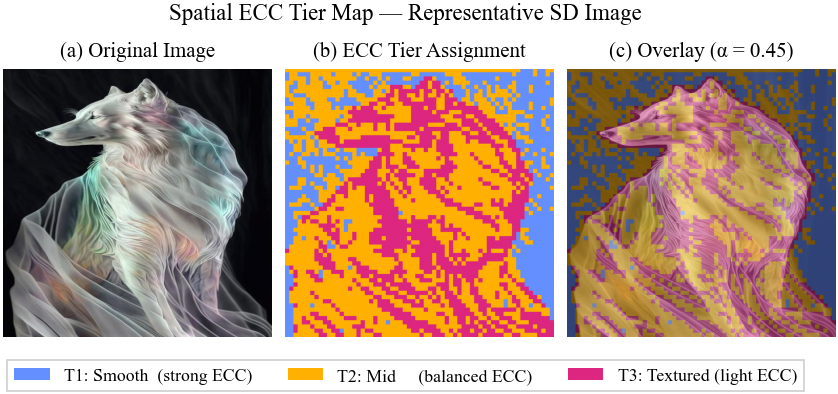

In [13]:
# Use the first image as the representative example
SAMPLE_IDX = 0
sample_img  = images[SAMPLE_IDX]
sample_vmap = var_maps[SAMPLE_IDX]   # shape: (H/8, W/8)

# Build an upscaled tier colour map (H x W x 3)
H, W = sample_img.shape[:2]
bH, bW = H // BLOCK_SIZE, W // BLOCK_SIZE

# Tier assignment per block
tier_map = np.zeros((bH, bW), dtype=np.uint8)
tier_map[sample_vmap >= tau_high] = 2          # T3: Textured
tier_map[(sample_vmap >= tau_low) &
          (sample_vmap < tau_high)] = 1         # T2: Mid
# T1: Smooth → already 0

# Map tiers to RGB colours
tier_colours = np.array([
    matplotlib.colors.to_rgb(PALETTE['smooth']),    # T1
    matplotlib.colors.to_rgb(PALETTE['mid']),       # T2
    matplotlib.colors.to_rgb(PALETTE['textured']),  # T3
])   # shape: (3, 3)

colour_map_small = tier_colours[tier_map]            # (bH, bW, 3)
# Upscale to original resolution using nearest-neighbour
colour_map_full = np.kron(
    colour_map_small,
    np.ones((BLOCK_SIZE, BLOCK_SIZE, 1))
)   # (H, W, 3)

# Convert sample image to RGB for matplotlib
sample_rgb = cv2.cvtColor(sample_img, cv2.COLOR_BGR2RGB)

# ─── Build Figure ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(7.16, 2.6),
                         gridspec_kw={'wspace': 0.05})

# Panel A: Original image
axes[0].imshow(sample_rgb)
axes[0].set_title('(a) Original Image', fontsize=10)
axes[0].axis('off')

# Panel B: Pure tier map
axes[1].imshow(colour_map_full)
axes[1].set_title('(b) ECC Tier Assignment', fontsize=10)
axes[1].axis('off')

# Panel C: Overlay (semi-transparent tier map on image)
overlay = 0.55 * sample_rgb / 255.0 + 0.45 * colour_map_full
overlay = np.clip(overlay, 0, 1)
axes[2].imshow(overlay)
axes[2].set_title('(c) Overlay (α = 0.45)', fontsize=10)
axes[2].axis('off')

# Legend patches
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=PALETTE['smooth'],   label='T1: Smooth  (strong ECC)'),
    Patch(facecolor=PALETTE['mid'],      label='T2: Mid     (balanced ECC)'),
    Patch(facecolor=PALETTE['textured'], label='T3: Textured (light ECC)'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=8.5, framealpha=0.95, bbox_to_anchor=(0.5, -0.01))

plt.suptitle('Spatial ECC Tier Map — Representative SD Image', fontsize=11, y=1.01)

out_path = RESULTS_DIR / 'fig02_tier_rate_map.pdf'
plt.savefig(out_path, bbox_inches='tight')
print(f'Saved → {out_path}')
plt.show()

---
## 6. LaTeX Table — Threshold Statistics

Generates the descriptive statistics table referenced in the paper (Table I). Copy-paste the output into your `.tex` file.

In [15]:
# ─── Compute Summary Stats for LaTeX Table ────────────────────────────────────
stats_dict = {
    'Statistic': ['Min', 'P10', 'P25 ($\\tau_{\\text{low}}$)', 'Median',
                  'P75 ($\\tau_{\\text{high}}$)', 'P90', 'Max', 'Mean', 'Std Dev'],
    'Value': [
        variances.min(),
        np.percentile(variances, 10),
        tau_low,
        np.median(variances),
        tau_high,
        np.percentile(variances, 90),
        variances.max(),
        variances.mean(),
        variances.std(),
    ],
    'Log\u2081\u2080 Value': [],
}
stats_dict['Log\u2081\u2080 Value'] = [
    np.log10(v + eps) for v in stats_dict['Value']
]

df_stats = pd.DataFrame(stats_dict)

# ─── Print IEEE-formatted LaTeX Table ─────────────────────────────────────────
latex_table = r"""
% ─── Table I: Block DCT Variance Distribution Statistics ─────────────────────
\begin{table}[t]
  \caption{Descriptive Statistics of 8$\times$8 Block DCT Variance
           Across 50 Stable Diffusion Images ($N = """ + f"{n_total:,}" + r""" Blocks)}
  \label{tab:variance_stats}
  \centering
  \begin{tabular}{lcc}
    \toprule
    \textbf{Statistic} & \textbf{Raw Value} & $\boldsymbol{\log_{10}}$\textbf{ Value} \\\\
    \midrule
"""

for _, row in df_stats.iterrows():
    latex_table += f"    {row['Statistic']} & {row['Value']:.4f} & {row['Log\u2081\u2080 Value']:.4f} \\\\\n"

latex_table += r"""
    \midrule
    \multicolumn{3}{l}{\textit{Tier distribution (by block count):}} \\\\
    \quad T1 Smooth   & """ + f"{n_smooth:,} ({100*n_smooth/n_total:.1f}\\%)" + r""" & \\\\
    \quad T2 Mid      & """ + f"{n_mid:,} ({100*n_mid/n_total:.1f}\\%)" + r""" & \\\\
    \quad T3 Textured & """ + f"{n_textured:,} ({100*n_textured/n_total:.1f}\\%)" + r""" & \\\\
    \bottomrule
  \end{tabular}
\end{table}
"""

print(latex_table)

# Also save to file
table_path = RESULTS_DIR / 'table01_variance_stats.tex'
table_path.write_text(latex_table, encoding='utf-8')
print(f'\nSaved → {table_path}')


% ─── Table I: Block DCT Variance Distribution Statistics ─────────────────────
\begin{table}[t]
  \caption{Descriptive Statistics of 8$\times$8 Block DCT Variance
           Across 50 Stable Diffusion Images ($N = 204,800 Blocks)}
  \label{tab:variance_stats}
  \centering
  \begin{tabular}{lcc}
    \toprule
    \textbf{Statistic} & \textbf{Raw Value} & $\boldsymbol{\log_{10}}$\textbf{ Value} \\\\
    \midrule
    Min & 0.0000 & -6.0000 \\
    P10 & 0.0000 & -6.0000 \\
    P25 ($\tau_{\text{low}}$) & 1.0178 & 0.0076 \\
    Median & 17.7702 & 1.2497 \\
    P75 ($\tau_{\text{high}}$) & 187.9512 & 2.2740 \\
    P90 & 810.8230 & 2.9089 \\
    Max & 11313.5332 & 4.0536 \\
    Mean & 276.5523 & 2.4418 \\
    Std Dev & 701.8728 & 2.8463 \\

    \midrule
    \multicolumn{3}{l}{\textit{Tier distribution (by block count):}} \\\\
    \quad T1 Smooth   & 51,178 (25.0\%) & \\\\
    \quad T2 Mid      & 102,422 (50.0\%) & \\\\
    \quad T3 Textured & 51,200 (25.0\%) & \\\\
    \bottomrule
  \end{tab

---
## 7. Summary

This notebook has produced:

| Output File | Description | Used In |
|---|---|---|
| `fig01_variance_distribution.pdf` | KDE of block DCT variance with tier boundaries | Section III.B, Fig. 1 |
| `fig02_tier_rate_map.pdf` | Spatial tier assignment overlay on sample image | Section III.B, Fig. 2 |
| `table01_variance_stats.tex` | Descriptive statistics LaTeX table | Section III.B, Table I |

**Next:** Run `02_ecc_rate_sweep.ipynb` to generate the Pareto frontier ablation figure.